In [2]:
from google.colab import files
dataset = files.upload()

Saving UPDATED_dataset_with_artist_pop.csv to UPDATED_dataset_with_artist_pop.csv


In [3]:
import pandas as pd

#check whether sustained vs brief is balanced
df = pd.read_csv('UPDATED_dataset_with_artist_pop.csv')
print(df.head())

      track_name    artist_name  danceability  energy  loudness  mode  key  \
0           Wow.    Post Malone         833.0   539.0    -7.399     0   11   
1           Wow.    Post Malone         833.0   539.0    -7.399     0   11   
2  thank u, next  Ariana Grande         724.0   647.0    -5.642     1    1   
3  thank u, next  Ariana Grande         724.0   647.0    -5.642     1    1   
4     Without Me         Halsey         752.0   488.0    -7.050     1    6   

   speechiness  acousticness  instrumentalness  ...  community_simplified  \
0     178.0000        163.00          0.000002  ...                     0   
1     178.0000        163.00          0.000002  ...                     0   
2       0.0658          0.28          0.000000  ...                 Other   
3       0.0658          0.28          0.000000  ...                 Other   
4       0.0705        297.00          0.000009  ...                     5   

   label_short_simplified                              label_long_si

In [4]:
df['chart_longevity'].value_counts()

,count
chart_longevity,
sustained,2006
brief,1743
unknown,771


In [5]:
#preprocessing

# Drop rows with missing target
df = df.dropna(subset=["chart_longevity"])

# Fill numeric NaNs with column medians
num_cols = ['danceability','energy','loudness','acousticness','instrumentalness',
            'liveness','tempo','duration_ms','year','max_artist_popularity']

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical NaNs with 'Unknown'
cat_cols = ['source','track_type','community','main_artist_genre','label_short','label_long']
df[cat_cols] = df[cat_cols].fillna('Unknown')


In [6]:
df = df[df['chart_longevity'].isin(['brief', 'sustained'])].copy()


In [7]:
df['chart_longevity'].isnull().sum()

np.int64(0)

In [8]:
df.value_counts('chart_longevity')

,count
chart_longevity,
sustained,2006
brief,1743


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix



# Features and target
X = df[['danceability','energy','loudness','acousticness','instrumentalness',
        'liveness','tempo','duration_ms','source','community','track_type',
        'is_cross','year','max_artist_popularity','main_artist_genre']]
y = df['chart_longevity'].map({'brief':0, 'sustained':1})

# Categorical and numeric columns
cat_cols = ['source','community','track_type','main_artist_genre']
num_cols = ['danceability','energy','loudness','acousticness','instrumentalness',
            'liveness','tempo','duration_ms','year','max_artist_popularity']

# Preprocessing
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

# Model pipeline
clf = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Train and evaluate
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.76      0.70      0.73       523
           1       0.76      0.81      0.78       602

    accuracy                           0.76      1125
   macro avg       0.76      0.75      0.75      1125
weighted avg       0.76      0.76      0.76      1125

[[366 157]
 [117 485]]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Class 0 (brief)

Precision: 0.76

Recall: 0.70

F1: 0.73

Class 1 (sustained)

Precision: 0.76

Recall: 0.81

F1: 0.78

Overall accuracy: 0.76

Macro F1: 0.75

Weighted F1: 0.76

justify why log regression not decision tree and why not k-folds cross validation

chart_longevity
1    0.535076
0    0.464924
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


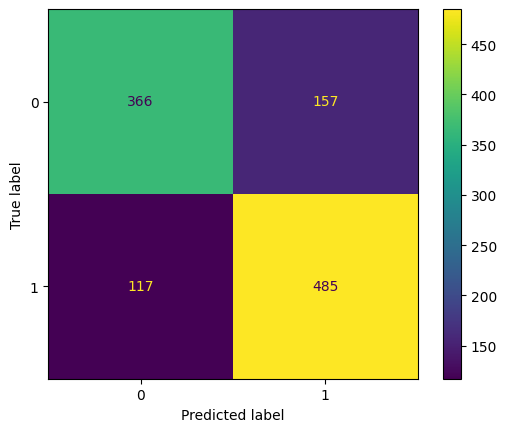

In [10]:
# 1. Check class balance in the whole dataset
print(y.value_counts(normalize=True))

# 2. Look at the confusion matrix you already computed
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)


In [12]:
import numpy as np

# Get the trained RF model from the pipeline
rf = clf.named_steps['model']

# Get the one-hot encoder to see how many dummy variables we got
ohe = clf.named_steps['preprocess'].named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(cat_cols)

all_feature_names = np.concatenate([num_cols, ohe_feature_names])

importances = rf.feature_importances_

# Sort and inspect top 20
idx = np.argsort(importances)[::-1]
for i in idx[:20]:
    print(all_feature_names[i], ":", importances[i])


loudness : 0.08189881822672548
tempo : 0.07727409351190105
danceability : 0.07704959728774144
duration_ms : 0.07682343477265735
liveness : 0.07622396748473433
acousticness : 0.07424908652963073
energy : 0.07335437847868727
max_artist_popularity : 0.0643716159075118
instrumentalness : 0.04823692328993268
year : 0.029036788799406684
track_type_spotify : 0.025194265518790854
main_artist_genre_german hip hop : 0.017158701346181797
community_16 : 0.010138186214153263
main_artist_genre_reggaeton : 0.009831736763319809
community_6 : 0.009236105247523043
main_artist_genre_rap : 0.008309700336911348
community_1 : 0.0080465116056724
community_5 : 0.007839550054979414
community_3 : 0.007284431335028869
community_2 : 0.007262641192871124


The model relies mainly on acoustic properties of the tracks to distinguish between brief and sustained chart longevity, and contextual features (genre, community, track type) appear to contribute much less predictive information. Acoustic features such as loudness, tempo, danceability, and energy play a central role in predicting sustained chart success, suggesting that stylistic and production characteristics of the audio may be more important than metadata-based descriptors like genre or community classification.

In [13]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Predictions
y_pred = clf.predict(X_test)

# Classification report as dict
report = classification_report(y_test, y_pred, output_dict=True)

# Turn into DataFrame
metrics_df = pd.DataFrame(report).T

# Add accuracy as a separate row if you want
accuracy = accuracy_score(y_test, y_pred)
metrics_df.loc['accuracy_overall', 'precision'] = accuracy

print(metrics_df)


                  precision    recall  f1-score      support
0                  0.757764  0.699809  0.727634   523.000000
1                  0.755452  0.805648  0.779743   602.000000
accuracy           0.756444  0.756444  0.756444     0.756444
macro avg          0.756608  0.752728  0.753688  1125.000000
weighted avg       0.756527  0.756444  0.755518  1125.000000
accuracy_overall   0.756444       NaN       NaN          NaN


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [14]:
metrics_display = metrics_df.loc[['0', '1', 'macro avg', 'weighted avg', 'accuracy_overall'],
                                 ['precision', 'recall', 'f1-score']]
metrics_display


,precision,recall,f1-score
0,0.757764,0.699809,0.727634
1,0.755452,0.805648,0.779743
macro avg,0.756608,0.752728,0.753688
weighted avg,0.756527,0.756444,0.755518
accuracy_overall,0.756444,NaN,NaN


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Extract trained RF and transformers
rf = clf.named_steps['model']
preprocess = clf.named_steps['preprocess']

ohe = preprocess.named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(cat_cols)

all_feature_names = np.concatenate([num_cols, ohe_feature_names])
importances = rf.feature_importances_

# Put into DataFrame
feat_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
})

# Sort and get top 20
feat_df = feat_df.sort_values(by='importance', ascending=False).head(20)

print(feat_df)


                              feature  importance
2                            loudness    0.081899
6                               tempo    0.077274
0                        danceability    0.077050
7                         duration_ms    0.076823
5                            liveness    0.076224
3                        acousticness    0.074249
1                              energy    0.073354
9               max_artist_popularity    0.064372
4                    instrumentalness    0.048237
8                                year    0.029037
439                track_type_spotify    0.025194
492  main_artist_genre_german hip hop    0.017159
25                       community_16    0.010138
535       main_artist_genre_reggaeton    0.009832
15                        community_6    0.009236
533             main_artist_genre_rap    0.008310
10                        community_1    0.008047
14                        community_5    0.007840
12                        community_3    0.007284


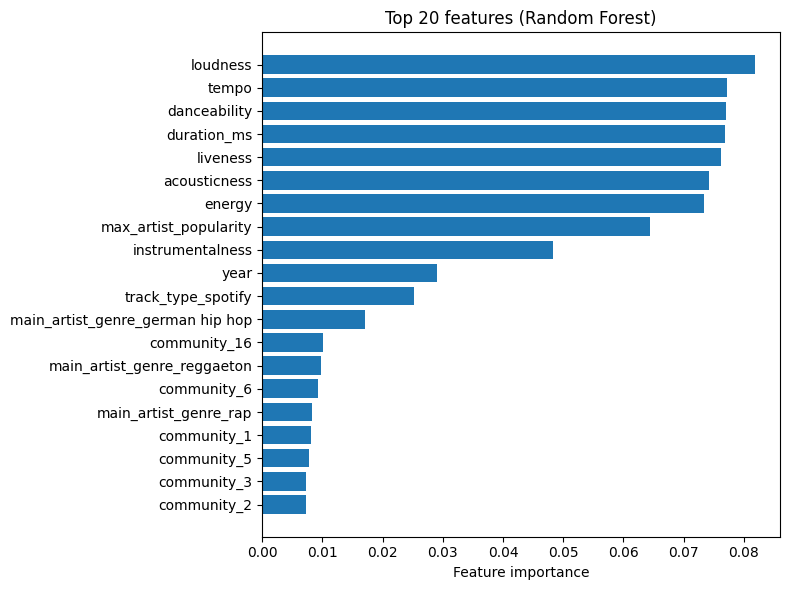

In [16]:
plt.figure(figsize=(8, 6))
plt.barh(feat_df['feature'], feat_df['importance'])
plt.gca().invert_yaxis()  # so the most important feature is on top
plt.xlabel('Feature importance')
plt.title('Top 20 features (Random Forest)')
plt.tight_layout()
plt.show()


In [17]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf,
    X,
    y,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=False
)

cv_results_df = pd.DataFrame(cv_results)
cv_results_df


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,5.105146,0.119785,0.745333,0.745921,0.796020,0.770156
1,3.371154,0.047572,0.774667,0.785714,0.795511,0.790582
2,2.594196,0.075048,0.780000,0.771889,0.835411,0.802395
3,2.669186,0.047841,0.760000,0.751708,0.822943,0.785714
4,2.129342,0.047222,0.774366,0.785714,0.795511,0.790582


In [19]:
cv_results_df.mean()



,0
fit_time,3.173805
score_time,0.067494
test_accuracy,0.766873
test_precision,0.768189
test_recall,0.809079
test_f1,0.787886


In [20]:
#performance tuning with GridSearchCV

param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}


In [21]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 400}
Best CV score: 0.7715898425329358


In [22]:
#test the tuned model

grid = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_clf = grid.best_estimator_
y_pred_best = best_clf.predict(X_test)

print(classification_report(y_test, y_pred_best))


              precision    recall  f1-score   support

           0       0.77      0.68      0.72       523
           1       0.75      0.82      0.78       602

    accuracy                           0.76      1125
   macro avg       0.76      0.75      0.75      1125
weighted avg       0.76      0.76      0.75      1125



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [24]:
cv_summary = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1'],
    'mean': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_f1'].mean()
    ],
    'std': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_f1'].std()
    ]
})

cv_summary


,metric,mean,std
0,accuracy,0.766873,0.012652
1,precision,0.768189,0.016706
2,recall,0.809079,0.016878
3,f1,0.787886,0.010432


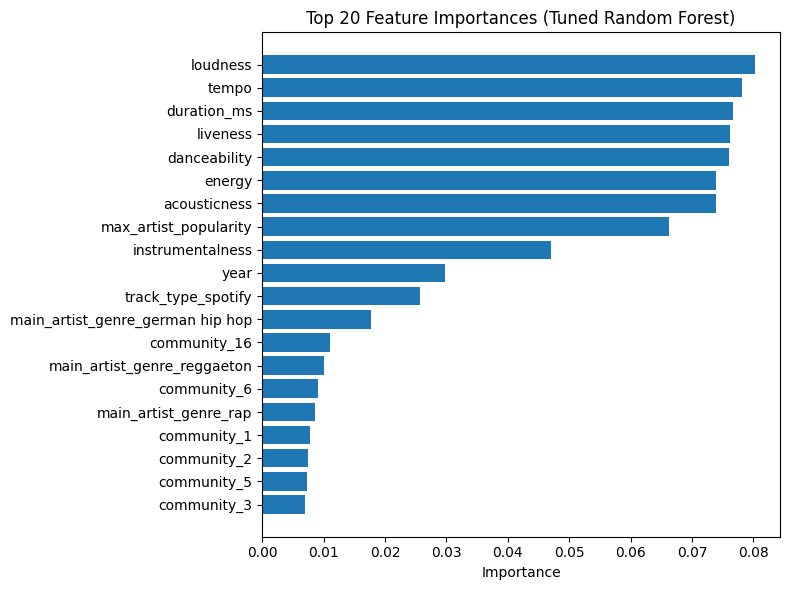

In [25]:
rf_best = best_clf.named_steps['model']
preprocess_best = best_clf.named_steps['preprocess']

ohe_best = preprocess_best.named_transformers_['cat']
ohe_feature_names_best = ohe_best.get_feature_names_out(cat_cols)

all_feature_names_best = np.concatenate([num_cols, ohe_feature_names_best])
importances_best = rf_best.feature_importances_

feat_df = pd.DataFrame({
    'feature': all_feature_names_best,
    'importance': importances_best
}).sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(8,6))
plt.barh(feat_df['feature'], feat_df['importance'])
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances (Tuned Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


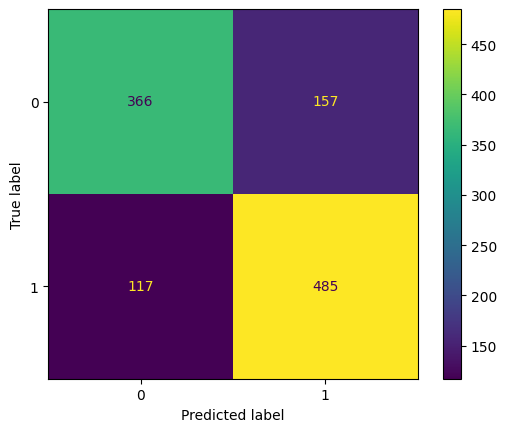

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)